# Neural network
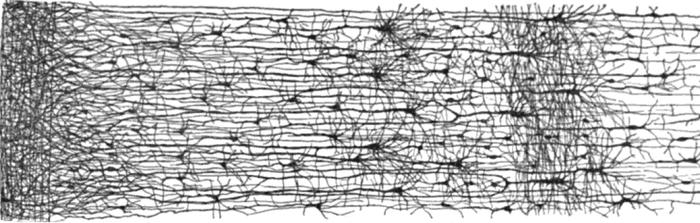
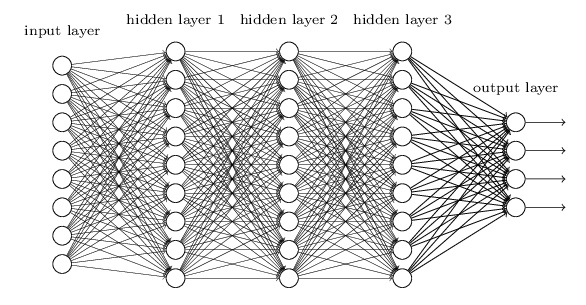


## Proper noun

- **Neural Network**：A computational model that mimics the structure and function of biological neural networks, composed of multiple neurons (nodes) interconnected with each other.

- **Neuron**：The basic unit of a neural network receives input signals, performs weighted summation and generates output through an activation function.

- **Activation Function**：Functions used to introduce nonlinear characteristics. Common activation functions include ReLU, Sigmoid and Tanh.

- **Weight**：The strength of the connections between neurons is adjusted through training to optimize the model performance.

- **Bias**：Additional parameters of neurons, used to adjust the output of neurons.

- **Loss Function**：Functions for measuring the difference between the model's prediction and the actual value, such as mean square Error (MSE) and Cross-Entropy Loss.

- **Optimizer**：Algorithms used to adjust model parameters to minimize the loss function, such as Stochastic Gradient Descent (SGD) and Adam.

- **Backpropagation**：The process of adjusting the weights layer by layer from the output layer to the input layer by calculating the gradient of the loss function to the weights.

- **Learning Rate**：The control optimizer adjusts the step size of the weights in each iteration.

- **Batch**：The number of samples input into the model at one time during the training process.

- **Iteration**：A complete process of forward propagation and backward propagation.

- **Epoch**：The training process in which the entire training dataset is traversed completely once.

- **Overfitting**：The phenomenon where a model performs well on training data but poorly on new data.

- **Regularization**：Techniques for preventing overfitting, such as L1 regularization, L2 regularization and Dropout.

- **Dropout**：During the training process, a portion of neurons are randomly ignored to prevent overfitting.

- **Pre-trained Model**：Pre-trained models on large-scale datasets can be used for fine-tuning specific tasks.

- **Embedding**：The technique of mapping discrete variables (such as words) to a continuous vector space.

- **Feature Extraction**：The process of extracting useful features from the original data.

- **Data Augmentation**：The technique of increasing data diversity by transforming the training data (such as rotating and flipping).

- **Batch Normalization**：Normalize the input of each layer to accelerate training and improve the stability of the model.

- **Vanishing Gradient**：In deep networks, the gradient gradually decreases during the backpropagation process, resulting in training difficulties.

- **Exploding Gradient**：In deep networks, the gradient gradually increases during the backpropagation process, resulting in unstable training.

- **Hyperparameter**：Parameters set before training, such as learning rate, batch size, etc.

- **Fine-tuning**：Based on the pre-trained model, make small-scale adjustments for specific tasks.

- **Attention Mechanism**：The technology that allows the model to focus on the important parts when processing data.

- **Adversarial Example**：The carefully designed input is intended to deceive the model into generating incorrect output.

- **Model Distillation**：The technique of transferring the knowledge of large models to small models.

- **Few-shot/Zero-shot Learning**：The technique of model prediction with few/without training samples.

- **Robustness**：The stability of the model when facing interferences such as noise and adversarial attacks.

## DNN

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

Epoch [1/10], Train Loss: 0.2357, Train Acc: 92.72%, Test Loss: 0.1072, Test Acc: 96.68%
Epoch [2/10], Train Loss: 0.1100, Train Acc: 96.60%, Test Loss: 0.0904, Test Acc: 97.13%
Epoch [3/10], Train Loss: 0.0849, Train Acc: 97.40%, Test Loss: 0.0827, Test Acc: 97.46%
Epoch [4/10], Train Loss: 0.0723, Train Acc: 97.76%, Test Loss: 0.0743, Test Acc: 97.72%
Epoch [5/10], Train Loss: 0.0622, Train Acc: 98.09%, Test Loss: 0.0703, Test Acc: 97.85%
Epoch [6/10], Train Loss: 0.0539, Train Acc: 98.30%, Test Loss: 0.0737, Test Acc: 97.92%
Epoch [7/10], Train Loss: 0.0504, Train Acc: 98.42%, Test Loss: 0.0748, Test Acc: 98.03%
Epoch [8/10], Train Loss: 0.0467, Train Acc: 98.55%, Test Loss: 0.0876, Test Acc: 97.64%
Epoch [9/10], Train Loss: 0.0450, Train Acc: 98.60%, Test Loss: 0.0753, Test Acc: 98.18%
Epoch [10/10], Train Loss: 0.0413, Train Acc: 98.70%, Test Loss: 0.0767, Test Acc: 98.15%


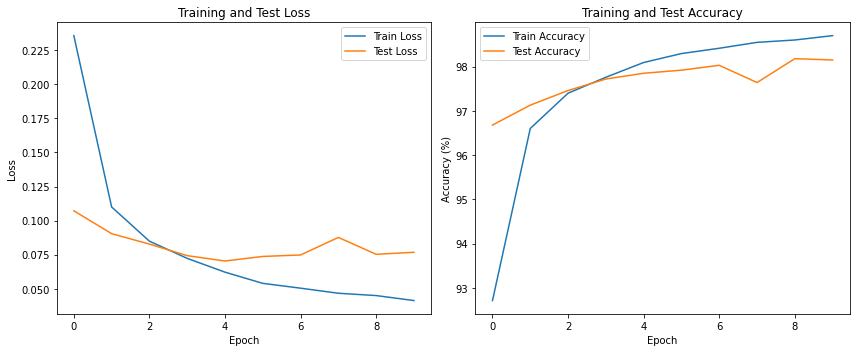

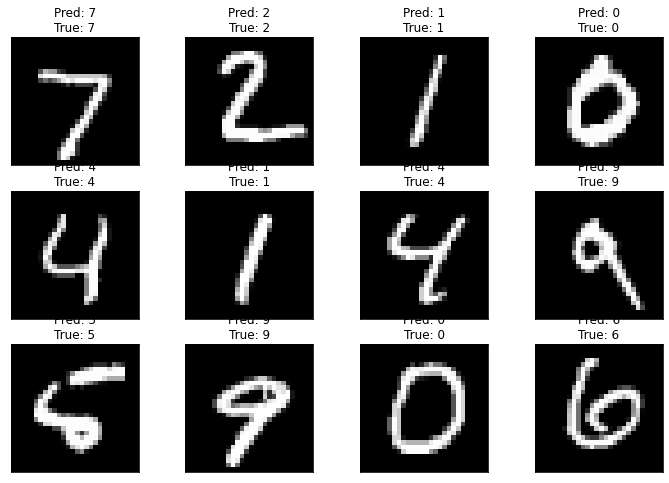

In [4]:
torch.manual_seed(42)

# 1. Data init
## transfer data from[0,255] to [0,1]
## about 90%+ data will in [-0.42, 0.72]
## adjust the data range second time by normalization
## different database has different coeffs 
## eg.
## CIFAR-10：mean=(0.4914, 0.4822, 0.4465), std=(0.2470, 0.2435, 0.2616)
## ImageNet：mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((0.1307,), (0.3081,)) # mean=0.137, sd=0.3081
])

# Download mnist database 
data_path = './mnist_data'
train_dataset = datasets.MNIST(root=data_path, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=data_path, train=False, download=True, transform=transform)

# create dataloader
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 2. define DNN model
class MNIST_DNN(nn.Module):
    def __init__(self):
        super(MNIST_DNN, self).__init__()
        self.flatten = nn.Flatten()  # flat 28x28 to 784
        self.fc1 = nn.Linear(28*28, 512)  # fc: full connection 
        self.relu1 = nn.ReLU()            # common activation function
        self.fc2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(256, 10)      # output layer,10 classes refer to [0,1,2,3,4,5,6,7,8,9]
        self.dropout = nn.Dropout(0.2)      # avoid overfitting
        
    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# model init
model = MNIST_DNN()

# 3. define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. train
num_epochs = 10
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        # forward
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # backward & opt
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # accuracy
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    
    # test
    model.eval()
    test_running_loss = 0.0
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            test_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
    
    test_loss = test_running_loss / len(test_loader)
    test_accuracy = 100 * test_correct / test_total
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)
    
    # rate of progress
    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, '
          f'Test Loss: {test_loss:.4f}, Test Acc: {test_accuracy:.2f}%')

# 5. draw
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Test Loss')

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Training and Test Accuracy')

plt.tight_layout()
plt.show()

def visualize_predictions():
    model.eval()
    with torch.no_grad():
        dataiter = iter(test_loader)
        images, labels = next(dataiter)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        fig = plt.figure(figsize=(12, 8))
        for idx in range(12):
            ax = fig.add_subplot(3, 4, idx+1, xticks=[], yticks=[])
            ax.imshow(images[idx].squeeze(), cmap='gray')
            ax.set_title(f'Pred: {predicted[idx].item()}\nTrue: {labels[idx].item()}')
        plt.show()

visualize_predictions()